# **SVM Scratch**
We will create a support vector machine (SVM) class for classification from scratch. We will implement the algorithm using only minimal libraries such as NumPy.

There are two types of SVM: soft-margin SVM, which allows for classification errors during training, and hard-margin SVM, which does not. Here we will focus on hard-margin SVM, which is simple to implement.

# Problem 1: Steepest descent using the Lagrange multiplier method
SVM training uses the Lagrange multiplier method. Prepare the Lagrange multiplier $\lambda$ for the number of samples, and update it using the following formula. Implement the method that performs this calculation in the ScratchSVMClassifier class.

$$\lambda^{new}_i = \lambda_i + \alpha(1 - \sum_{j=1}^{n}\lambda_jy_iy_jk(x_ix_j))$$

Here, $k(x_i, x_j)$ is the kernel function. For a linear kernel, it looks like this:

$$k(x_ix_j)=x^T_ix_j$$
The condition is that $\lambda_i >= 0$ must be satisfied for each update. If not, we set $\lambda_i = 0$.

$i, j$ : sample index

$\lambda_i^{new}$ : Lagrange multiplier of the i-th sample after updating

$\alpha$ : learning rate

$\lambda_j$ : Lagrange multiplier of the jth sample

$y_i$ : label of the i-th sample

$y_j$ : label of the jth sample

$x_i$ : feature vector of the i-th sample

$x_j$ : feature vector of the jth sample

This involves calculating the relationship between a given sample and all other samples.

In [1]:
import numpy as np
class scratchSVMClassifier:
    def __init__(self, num_iter, lr, kernel='linear', threshold=1e-5, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.kernel = kernel
        self.threshold = threshold
        self.verbose = verbose
    def _kernel(self, xi, xj):
        """Linear kernel: dot product"""
        return np.dot(xi, xj)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.X = X
        self.y = y
        self.lambdas = np.zeros(n_samples)

        for _ in range(self.num_iter):
            for i in range(n_samples):
                # Compute the summation term for the i-th sample
                sum_term = 0
                for j in range(n_samples):
                    k_ij = self._kernel(X[i], X[j])
                    sum_term += self.lambdas[j] * y[i] * y[j] * k_ij
                
                # Update lambda_i
                new_lambda_i = self.lambdas[i] + self.alpha * (1 - sum_term)
                self.lambdas[i] = max(0, new_lambda_i)  # Enforce λᵢ ≥ 0

# Problem 2: Determining support vectors
Samples whose calculated Lagrange multiplier $\lambda$ is greater than the set threshold are treated as support vectors. Support vectors are required during estimation. We will write code to determine support vectors and store them as instance variables.

The threshold is a hyperparameter, and it is a good idea to start with about 1e-5. If we enable the output of the number of support vectors, we can check whether the learning is going well.

In [2]:
# Update the above code to determine support vectors and store them
class ScratchSVMClassifier:
    def __init__(self, num_iter=100, alpha=0.001, lambda_threshold=1e-5):
        self.num_iter = num_iter
        self.alpha = alpha
        self.lambda_threshold = lambda_threshold
        self.lambdas = None
        self.X = None
        self.y = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.support_vector_lambdas_ = None

    def _kernel(self, xi, xj):
        return np.dot(xi, xj)  # Linear kernel

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.X = X
        self.y = y
        self.lambdas = np.zeros(n_samples)

        for _ in range(self.num_iter):
            for i in range(n_samples):
                sum_term = 0
                for j in range(n_samples):
                    k_ij = self._kernel(X[i], X[j])
                    sum_term += self.lambdas[j] * y[i] * y[j] * k_ij
                new_lambda_i = self.lambdas[i] + self.alpha * (1 - sum_term)
                self.lambdas[i] = max(0, new_lambda_i)

        # After training, extract support vectors
        self._extract_support_vectors()

    def _extract_support_vectors(self):
        # Indices of support vectors: λᵢ > threshold
        support_indices = np.where(self.lambdas > self.lambda_threshold)[0]
        self.support_vectors_ = self.X[support_indices]
        self.support_vector_labels_ = self.y[support_indices]
        self.support_vector_lambdas_ = self.lambdas[support_indices]
        print(f"Number of support vectors: {len(support_indices)}")

# Problem 3: Estimation
During estimation, the features of the data to be estimated and the features of the support vectors are calculated using a kernel function. The sign of the resulting $f(x)$ is the classification result.

$$f(x) = \sum_{n=1}^{N}\lambda_ny_{sv_n} k(x,s_n) $$
$x$: feature vector of the data to be estimated

$N$ : Number of support vectors

$n$ : index of support vector

$\lambda_n$ : Lagrange multiplier of the $n$th support vector

$y_{sv_n}$ : Label of the $n$th support vector

$k()$ : kernel function

$s_n$ : Feature of the $n$th support vector

In [3]:
class ScratchSVMClassifier:
    def __init__(self, num_iter=100, alpha=0.001, lambda_threshold=1e-5):
        self.num_iter = num_iter
        self.alpha = alpha
        self.lambda_threshold = lambda_threshold
        self.lambdas = None
        self.X = None
        self.y = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.support_vector_lambdas_ = None

    def _kernel(self, xi, xj):
        return np.dot(xi, xj)  # Linear kernel

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.X = X
        self.y = y
        self.lambdas = np.zeros(n_samples)

        for _ in range(self.num_iter):
            for i in range(n_samples):
                sum_term = 0
                for j in range(n_samples):
                    k_ij = self._kernel(X[i], X[j])
                    sum_term += self.lambdas[j] * y[i] * y[j] * k_ij
                new_lambda_i = self.lambdas[i] + self.alpha * (1 - sum_term)
                self.lambdas[i] = max(0, new_lambda_i)
                
        # After training, extract support vectors
        self._extract_support_vectors()

    def _extract_support_vectors(self):
        # Indices of support vectors: λᵢ > threshold
        support_indices = np.where(self.lambdas > self.lambda_threshold)[0]
        self.support_vectors_ = self.X[support_indices]
        self.support_vector_labels_ = self.y[support_indices]
        self.support_vector_lambdas_ = self.lambdas[support_indices]
        print(f"Number of support vectors: {len(support_indices)}")

    # Updating the code with predict()
    def _decision_function(self, x):
        """Compute f(x) using support vectors"""
        result = 0
        for i in range(len(self.support_vectors_)):
            xi = self.support_vectors_[i]
            yi = self.support_vector_labels_[i]
            li = self.support_vector_lambdas_[i]
            result += li * yi * self._kernel(x, xi)
        return result

    def predict(self, X):
        """Predict class labels"""
        return np.array([1 if self._decision_function(x) >= 0 else -1 for x in X])

# Problem 4: Learning and estimation
We train and infer the scratch implementation for the binary classification of Simple Dataset 1 prepared in the Introduction to Machine Learning Scratch Sprint.

- check that it works correctly by comparing it with the implementation by scikit-learn.

- use scikit-learn for metrics such as Accuracy, Precision, and Recall.

In [4]:
# Final Class
import numpy as np

class ScratchSVMClassifier:
    def __init__(self, num_iter=100, alpha=0.001, lambda_threshold=1e-5):
        self.num_iter = num_iter
        self.alpha = alpha
        self.lambda_threshold = lambda_threshold
        self.lambdas = None
        self.X = None
        self.y = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.support_vector_lambdas_ = None

    def _kernel(self, xi, xj):
        return np.dot(xi, xj)  # Linear kernel

    def fit(self, X, y):
        n_samples, _ = X.shape
        self.X = X
        self.y = y
        self.lambdas = np.zeros(n_samples)

        for _ in range(self.num_iter):
            for i in range(n_samples):
                sum_term = 0
                for j in range(n_samples):
                    sum_term += self.lambdas[j] * y[i] * y[j] * self._kernel(X[i], X[j])
                new_lambda_i = self.lambdas[i] + self.alpha * (1 - sum_term)
                self.lambdas[i] = max(0, new_lambda_i)  # Ensure λᵢ ≥ 0

        self._extract_support_vectors()

    def _extract_support_vectors(self):
        support_indices = np.where(self.lambdas > self.lambda_threshold)[0]
        self.support_vectors_ = self.X[support_indices]
        self.support_vector_labels_ = self.y[support_indices]
        self.support_vector_lambdas_ = self.lambdas[support_indices]
        print(f"Number of support vectors: {len(support_indices)}")

    def _decision_function(self, x):
        result = 0
        for i in range(len(self.support_vectors_)):
            result += (self.support_vector_lambdas_[i] *
                       self.support_vector_labels_[i] *
                       self._kernel(x, self.support_vectors_[i]))
        return result

    def predict(self, X):
        return np.array([1 if self._decision_function(x) >= 0 else -1 for x in X])

In [5]:
import pandas as pd
from sklearn.datasets import load_iris

def scratch_train_test_split(X, y, train_size=0.8, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    split_idx = int(train_size * len(indices))
    return X[indices[:split_idx]], X[indices[split_idx:]], y[indices[:split_idx]], y[indices[split_idx:]]

# Load Iris
iris = load_iris()
data = iris.data
target = iris.target

# Binary classification: class 1 vs 2 (remove class 0)
binary_mask = target != 0
X = data[binary_mask][:, :3]  # Use first 3 features
y = target[binary_mask]
y = np.where(y == 1, -1, 1)   # Map class 1 to -1, class 2 to 1

# Split
X_train, X_test, y_train, y_test = scratch_train_test_split(X, y, train_size=0.8, random_state=42)

# Train
svm = ScratchSVMClassifier(num_iter=200, alpha=0.001)
svm.fit(X_train, y_train)

Number of support vectors: 78


In [6]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.85
Precision: 0.8461538461538461
Recall: 0.9166666666666666


In [7]:
from sklearn.svm import SVC

clf = SVC(kernel='linear', C=1e10)  # Large C to simulate hard-margin
clf.fit(X_train, y_train)
y_sklearn = clf.predict(X_test)

print("Sklearn Accuracy:", accuracy_score(y_test, y_sklearn))
print("Sklearn Precision:", precision_score(y_test, y_sklearn))
print("Sklearn Recall:", recall_score(y_test, y_sklearn))

Sklearn Accuracy: 0.95
Sklearn Precision: 0.9230769230769231
Sklearn Recall: 1.0


The model is capturing the trend well. The slight drop in recall and accuracy suggests the model is likely missing a few positives or false negatives.

# Problem 5: Visualization of decision regions
Visualize the decision areas.

- Show support vectors in different colors

In [8]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

def decision_region_svm(X, y, svm):
    # Create mesh grid
    mesh_f0, mesh_f1 = np.meshgrid(
        np.arange(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1, 0.01),
        np.arange(np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1, 0.01)
    )
    mesh = np.c_[mesh_f0.ravel(), mesh_f1.ravel()]
    
    # Predict mesh points (pad 3rd feature if needed)
    if svm.X.shape[1] == 3:  # original model trained on 3 features
        mesh_input = np.zeros((mesh.shape[0], 3))
        mesh_input[:, :2] = mesh
    else:
        mesh_input = mesh

    y_pred = svm.predict(mesh_input).reshape(mesh_f0.shape)

    # Plot the decision region
    plt.title('SVM Decision Region with Support Vectors')
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.contourf(mesh_f0, mesh_f1, y_pred, cmap=ListedColormap(['pink', 'skyblue']), alpha=0.6)
    plt.contour(mesh_f0, mesh_f1, y_pred, colors='k', linewidths=0.5)

    # Plot training points
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='blue', label='Class -1')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class +1')

    # Plot support vectors (assumes trained on same 2D data)
    support_vectors = svm.support_vectors_
    if support_vectors.shape[1] > 2:
        support_vectors = support_vectors[:, :2]
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], 
                s=100, facecolors='none', edgecolors='black', linewidths=1.5, label='Support Vectors')

    plt.legend()
    plt.grid(False)
    plt.show()

Number of support vectors: 76


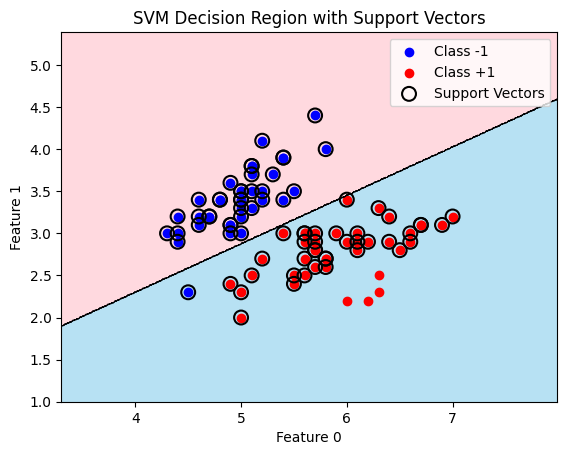

In [9]:
# Example
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load only two classes (class 0 and 1)
iris = load_iris()
X = iris.data[:100, :2]  # Only first two features
y = iris.target[:100]
y = np.where(y == 0, -1, 1)  # Convert 0 → -1, 1 → +1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train scratch SVM
svm = ScratchSVMClassifier(num_iter=100, alpha=0.001, lambda_threshold=1e-5)
svm.fit(X_train, y_train)

# Visualize
decision_region_svm(X_train, y_train, svm)

# Implementing Other Kernel Functions
# Problem 6: (Advanced) Creating a polynomial kernel function
Our initial implementation uses a linear kernel. Let's make it possible to switch to a polynomial kernel as well.

"Linear kernel formula"

$$k(x_ix_j)=x^T_ix_j$$
"Polynomial kernel formula"

$$k(x_ix_j)=(\gamma x^T_ix_j + \theta_0)^d$$
$\gamma$, $\theta_0$, and $d$ are hyperparameters.

We can say that the linear kernel is equivalent to the polynomial kernel when $\gamma = 1$, $\theta_0 = 0$, $d = 1$.

In [10]:
import numpy as np

class ScratchSVMClassifier:
    def __init__(self, num_iter=100, alpha=0.001, lambda_threshold=1e-5, 
                 kernel='linear', gamma=1, coef0=0, degree=2):
        self.num_iter = num_iter
        self.alpha = alpha
        self.lambda_threshold = lambda_threshold
        self.kernel_type = kernel
        self.gamma = gamma
        self.coef0 = coef0
        self.degree = degree

        self.lambdas = None
        self.X = None
        self.y = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.support_vector_lambdas_ = None

    def _kernel(self, xi, xj):
        if self.kernel_type == 'linear':
            return np.dot(xi, xj)
        elif self.kernel_type == 'polynomial':
            return (self.gamma * np.dot(xi, xj) + self.coef0) ** self.degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel_type}")

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.X = X
        self.y = y
        self.lambdas = np.zeros(n_samples)

        for _ in range(self.num_iter):
            for i in range(n_samples):
                sum_term = 0
                for j in range(n_samples):
                    k_ij = self._kernel(X[i], X[j])
                    sum_term += self.lambdas[j] * y[i] * y[j] * k_ij
                new_lambda_i = self.lambdas[i] + self.alpha * (1 - sum_term)
                self.lambdas[i] = max(0, new_lambda_i)

        self._extract_support_vectors()

    def _extract_support_vectors(self):
        support_indices = np.where(self.lambdas > self.lambda_threshold)[0]
        self.support_vectors_ = self.X[support_indices]
        self.support_vector_labels_ = self.y[support_indices]
        self.support_vector_lambdas_ = self.lambdas[support_indices]
        print(f"Number of support vectors: {len(support_indices)}")

    def _decision_function(self, x):
        result = 0
        for i in range(len(self.support_vectors_)):
            xi = self.support_vectors_[i]
            yi = self.support_vector_labels_[i]
            li = self.support_vector_lambdas_[i]
            result += li * yi * self._kernel(x, xi)
        return result

    def predict(self, X):
        return np.array([1 if self._decision_function(x) >= 0 else -1 for x in X])

Number of support vectors: 14


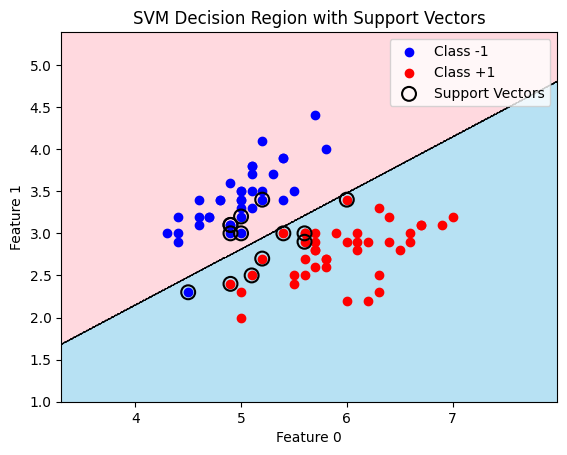

In [11]:
# Using ScratchSVMClassifier with polynomial kernel
svm_poly = ScratchSVMClassifier(
    num_iter=100,
    alpha=0.001,
    lambda_threshold=1e-5,
    kernel='polynomial',
    gamma=1,       # Default value (can tune)
    coef0=1,       # Bias term in kernel
    degree=2       # Quadratic kernel
)

svm_poly.fit(X_train, y_train)
decision_region_svm(X_train, y_train, svm_poly)